# 1.3 Fetch POI Features (community area + H3)

Gathers **Points-of-Interest (POI)** features for Chicago from **OpenStreetMap** via the [Overpass API](https://wiki.openstreetmap.org/wiki/Overpass_API).

POI features are static per cell (they don't change over time); in the demand dataset they describe what kind of place each cell is — useful context for the descriptive analysis ("why is demand high here?") and as model features.

**Features per spatial unit**

| Feature | Kind | Why it relates to taxi demand |
|---|---|---|
| `dist_to_nearest_airport_km` | distance | O'Hare / Midway are the biggest taxi generators |
| `dist_to_nearest_train_station_km` | distance | rail access (feeder trips / substitution) |
| `dist_to_nearest_stadium_km` | distance | event-driven surge demand |
| `restaurants_per_km2` | density | dining → evening demand |
| `bars_and_clubs_per_km2` | density | nightlife → late-night / weekend demand |
| `hotels_per_km2` | density | tourists / business travel → airport & downtown trips |
| `hospitals_per_km2` | density | hospitals are large, steady trip generators |
| `universities_per_km2` | density | campuses generate many trips |
| `train_station_per_km2` | density | transit-hub intensity |
| `attractions_per_km2` | density | museums / attractions → tourist demand |
| `poi_density_total_per_km2` | density | overall commercial "vibrancy" of the cell |
| `area_km2` | size | cell area — relevant when comparing spatial resolutions |

### Data Requirements
1. `Boundaries_Community_Areas_20260608.geojson` — `data/geometry/Boundaries_Community_Areas_20260608.geojson`

### Outputs
- `data/poi/poi_features_community_area.parquet` / `.csv` — key `community_area`
- `data/poi/poi_features_h3.parquet` / `.csv` — key `resolution` + `h3_cell` (res 6 & 7)

## Setup

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import h3
from shapely.geometry import Point, Polygon

import requests
import requests_cache

import matplotlib.pyplot as plt

In [2]:
# Reset working directory to the project root (folder containing pyproject.toml)
import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/hendrik/Coding/Master/AAA


In [3]:
# # # # # # # # #  Configuration  # # # # # # # # #
CA_GEOJSON = "data/geometry/Boundaries_Community_Areas_20260608.geojson"
OUT_DIR    = "data/poi"

# Metric CRS for the Chicago region (NAD83 / Illinois East, units = metres)
METRIC_CRS = 26971

# H3 resolutions, matching the demand pipeline (pickup_h3_res6 / pickup_h3_res7)
RESOLUTIONS = {"low": 6, "medium": 7}

# Public Overpass mirrors, tried in rotation with retries (overpass-api.de first
# because the community mirrors are often overloaded).
OVERPASS_ENDPOINTS = [
    "https://overpass-api.de/api/interpreter",
    "https://overpass.private.coffee/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter",
]
HTTP_HEADERS = {
    "User-Agent": "AAA-taxi-research/1.0 (academic project; POI feature fetch)",
    "Content-Type": "text/plain",
}

# POI categories. `features` says which feature(s) to derive:
#   "distance" -> km from the unit centroid to the nearest POI of this kind
#   "density"  -> POIs within the unit: absolute count + count per km2
# Column names are derived from the category key.
CATEGORIES = {
    "airport": {  # only aerodromes with an IATA code => real commercial airports
        "features": ["distance"],
        "filters": ['["aeroway"="aerodrome"]["iata"]'],
    },
    "train_station": {  # CTA 'L', Metra, Amtrak -> both "how far" and "how many"
        "features": ["distance", "density"],
        "filters": ['["railway"="station"]', '["railway"="halt"]'],
    },
    "stadium": {
        "features": ["distance"],
        "filters": ['["leisure"="stadium"]', '["building"="stadium"]'],
    },
    "restaurants": {
        "features": ["density"],
        "filters": ['["amenity"="restaurant"]'],
    },
    "bars_and_clubs": {
        "features": ["density"],
        "filters": ['["amenity"="bar"]', '["amenity"="pub"]', '["amenity"="nightclub"]'],
    },
    "hotels": {
        "features": ["density"],
        "filters": ['["tourism"="hotel"]'],
    },
    "hospitals": {
        "features": ["density"],
        "filters": ['["amenity"="hospital"]'],
    },
    "universities": {
        "features": ["density"],
        "filters": ['["amenity"="university"]', '["amenity"="college"]'],
    },
    "attractions": {  # tourist draw; replaces the low-variance "landmark" distance
        "features": ["density"],
        "filters": ['["tourism"="attraction"]', '["tourism"="museum"]', '["tourism"="gallery"]'],
    },
}

os.makedirs(OUT_DIR, exist_ok=True)

# Cache Overpass responses so re-runs are instant and we stay polite to the mirrors.
session = requests_cache.CachedSession(
    os.path.join(OUT_DIR, ".overpass_cache_v2"), expire_after=None
)
print(f"{len(CATEGORIES)} POI categories configured")

9 POI categories configured


## 1. Load community areas & define the query area

The 77 community-area polygons define the city. Their bounding box (padded so POIs
just outside the boundary are still found for edge cells) is the OpenStreetMap query
area.

In [4]:
community_areas = gpd.read_file(CA_GEOJSON).to_crs(4326)
community_areas["community_area"] = community_areas["area_numbe"].astype(int)
community_areas = community_areas[["community_area", "community", "geometry"]]

# Overpass bbox is "south,west,north,east"; pad by ~0.15 deg (~15 km)
west, south, east, north = community_areas.total_bounds
PAD = 0.15
BBOX = f"{south - PAD},{west - PAD},{north + PAD},{east + PAD}"

print(f"Community areas: {len(community_areas)}")
print(f"Query bbox (S,W,N,E): {BBOX}")
community_areas.head()

Community areas: 77
Query bbox (S,W,N,E): 41.494543121506055,-88.0901140825235,42.173038586147584,-87.37413710389522


,community_area,community,geometry
0,1,ROGERS PARK,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ..."
1,2,WEST RIDGE,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ..."
2,3,UPTOWN,"MULTIPOLYGON (((-87.64102 41.9548, -87.644 41...."
3,4,LINCOLN SQUARE,"MULTIPOLYGON (((-87.67441 41.9761, -87.6744 41..."
4,5,NORTH CENTER,"MULTIPOLYGON (((-87.67336 41.93234, -87.67342 ..."


## 2. Fetch POIs from OpenStreetMap

For each category we build one Overpass QL query unioning all its tag selectors over
nodes, ways and relations. `out center;` returns one representative coordinate for
ways/relations, so every POI becomes a single point.

In [5]:
def build_overpass_query(filters, bbox):
    """Union all tag selectors over node/way/relation within the bbox."""
    body = "\n".join(
        f"  {element}{flt}({bbox});"
        for flt in filters
        for element in ("node", "way", "relation")
    )
    return f"[out:json][timeout:180];\n(\n{body}\n);\nout center;"


def fetch_overpass(filters, bbox, retries=6):
    """Run a query against the Overpass mirrors with retries + caching."""
    query = build_overpass_query(filters, bbox)
    last_error = None
    for attempt in range(retries):
        endpoint = OVERPASS_ENDPOINTS[attempt % len(OVERPASS_ENDPOINTS)]
        try:
            resp = session.post(endpoint, data=query.encode("utf-8"),
                                headers=HTTP_HEADERS, timeout=300)
            if resp.status_code == 200:
                return resp.json()["elements"]
            last_error = f"{endpoint} -> HTTP {resp.status_code}"
        except Exception as exc:  # network / decode errors -> retry next mirror
            last_error = f"{endpoint} -> {type(exc).__name__}"
        time.sleep(2 * (attempt + 1))
    raise RuntimeError(f"Overpass failed after {retries} attempts: {last_error}")


def elements_to_points(elements):
    """Convert Overpass elements to a GeoDataFrame of points (EPSG:4326)."""
    pts = []
    for el in elements:
        if el["type"] == "node":
            pts.append(Point(el["lon"], el["lat"]))
        else:  # way / relation -> 'center' from `out center;`
            c = el.get("center")
            if c:
                pts.append(Point(c["lon"], c["lat"]))
    return gpd.GeoDataFrame(geometry=pts, crs=4326)

In [6]:
# Fetch every category once (cached). POIs just outside the city are fine:
# distance features only care about the nearest POI, counts only about POIs inside a cell.
poi_layers = {}
for name, cfg in CATEGORIES.items():
    elements = fetch_overpass(cfg["filters"], BBOX)
    poi_layers[name] = elements_to_points(elements)
    print(f"{name:16s} {'/'.join(cfg['features']):16s} -> {len(poi_layers[name]):6,d} POIs")
    time.sleep(1)  # be polite between queries

airport          distance         ->      5 POIs
train_station    distance/density ->    344 POIs


KeyboardInterrupt: 

## 3. Feature engineering

One function computes every feature for any layer of spatial units (community areas *or* H3 hexagons), so both grids are treated identically:

- **distance** → project to metres, take each unit's centroid, `sjoin_nearest` to the closest POI, report km.
- **density** → spatial-join POIs lying *within* each unit → absolute `count_*` and`*_per_km2` (count / unit area).
- a final **`poi_density_total_per_km2`** sums all density categories → an overall commercial-activity index for the cell.

In [ ]:
def compute_poi_features(units, id_col, poi_layers):
    """Compute all POI features for a layer of spatial units keyed by `id_col`."""
    units_m = units.to_crs(METRIC_CRS).copy()
    units_m["area_km2"] = units_m.geometry.area / 1e6

    centroids = units_m.copy()
    centroids["geometry"] = units_m.geometry.centroid

    feats = units_m[[id_col, "area_km2"]].reset_index(drop=True).copy()
    count_cols = []

    for name, cfg in CATEGORIES.items():
        poi = poi_layers.get(name)
        poi_m = None if (poi is None or poi.empty) else poi.to_crs(METRIC_CRS)[["geometry"]]

        if "distance" in cfg["features"]:
            col = f"dist_to_nearest_{name}_km"
            if poi_m is None:
                feats[col] = np.nan
            else:
                nearest = gpd.sjoin_nearest(centroids[[id_col, "geometry"]], poi_m,
                                            how="left", distance_col="_dist_m")
                # ties can give >1 row per unit -> keep the minimum
                feats[col] = feats[id_col].map(nearest.groupby(id_col)["_dist_m"].min() / 1000.0)

        if "density" in cfg["features"]:
            count_col, dens_col = f"count_{name}", f"{name}_per_km2"
            if poi_m is None:
                feats[count_col], feats[dens_col] = 0, 0.0
            else:
                inside = gpd.sjoin(poi_m, units_m[[id_col, "geometry"]], predicate="within")
                feats[count_col] = feats[id_col].map(inside.groupby(id_col).size()).fillna(0).astype(int)
                feats[dens_col] = feats[count_col] / feats["area_km2"]
            count_cols.append(count_col)

    # overall commercial-activity index (sum of all counted categories per km2)
    feats["poi_density_total_per_km2"] = feats[count_cols].sum(axis=1) / feats["area_km2"]
    return feats

## 4. Community-area features

Keyed by `community_area`, ready to join onto `pickup_community_area`.

In [ ]:
ca_features = compute_poi_features(community_areas, "community_area", poi_layers)

ca_pq, ca_csv = f"{OUT_DIR}/poi_features_community_area.parquet", f"{OUT_DIR}/poi_features_community_area.csv"
ca_features.to_parquet(ca_pq, index=False)
ca_features.to_csv(ca_csv, index=False)
print(f"Saved {len(ca_features)} community areas -> {ca_pq}")
ca_features.describe().round(2)

Saved 77 community areas -> data/poi/poi_features_community_area.parquet


,community_area,area_km2,dist_to_nearest_airport_km,dist_to_nearest_train_station_km,count_train_station,train_station_per_km2,dist_to_nearest_stadium_km,count_restaurants,restaurants_per_km2,count_bars_and_clubs,bars_and_clubs_per_km2,count_hotels,hotels_per_km2,count_hospitals,hospitals_per_km2,count_universities,universities_per_km2,count_attractions,attractions_per_km2,poi_density_total_per_km2
count,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00
mean,39.00,7.77,11.95,1.00,2.65,0.42,3.04,30.74,4.47,12.45,1.72,2.36,0.39,0.55,0.07,0.82,0.13,2.69,0.41,7.62
std,22.37,5.10,4.58,0.79,3.29,0.62,1.70,58.52,8.38,24.37,3.21,10.94,1.88,0.94,0.12,1.94,0.34,7.53,1.17,14.62
min,1.00,1.57,1.06,0.11,0.00,0.00,0.28,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,20.00,4.62,9.25,0.42,1.00,0.09,1.79,3.00,0.35,1.00,0.16,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.08
50%,39.00,7.40,12.36,0.71,2.00,0.34,2.88,7.00,1.09,3.00,0.45,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.96
75%,58.00,9.18,15.33,1.34,4.00,0.60,4.24,29.00,4.62,9.00,1.49,1.00,0.08,1.00,0.12,1.00,0.13,2.00,0.24,6.83
max,77.00,34.54,20.78,3.56,22.00,5.11,7.50,312.00,44.83,122.00,17.13,80.00,12.31,5.00,0.66,10.00,2.32,48.00,6.74,83.86


## 5. H3-hexagon features (low = res 6, medium = res 7)

We tile the community-area footprint with H3 cells at each resolution and compute the
same features per hexagon. Resolutions are stacked into one table with a `resolution`
column, keyed by `h3_cell` — ready to join onto `pickup_h3_res6` / `pickup_h3_res7`.

In [ ]:
def build_h3_layer(area_gdf, resolution):
    """Cover the footprint of `area_gdf` with H3 cells at the given resolution.

    geo_to_cells keeps only cells whose *centre* lies inside the polygon, so coarse hexes
    overlapping the city edge (centre just outside) would be missed. We buffer the footprint
    by ~1.5 hex edge-lengths first: any hex that overlaps the real city then has its centre
    inside the buffer, so the layer covers every cell that touches the city (matches the trips).
    Edge cells still get correct features because the POI point layers span the padded bbox.
    """
    edge_km = h3.average_hexagon_edge_length(resolution, unit="km")
    footprint = (area_gdf.to_crs(METRIC_CRS).buffer(1.5 * edge_km * 1000)
                 .to_crs(4326).union_all())
    parts = footprint.geoms if footprint.geom_type == "MultiPolygon" else [footprint]

    cells = set()
    for part in parts:
        cells.update(h3.geo_to_cells(part.__geo_interface__, resolution))
    cells = sorted(cells)

    # h3.cell_to_boundary returns (lat, lon) -> flip to (lon, lat) for shapely
    polys = [Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(c)]) for c in cells]
    return gpd.GeoDataFrame({"h3_cell": cells, "geometry": polys}, crs=4326)

In [ ]:
h3_frames = []
for res_name, res_level in RESOLUTIONS.items():
    hex_layer = build_h3_layer(community_areas, res_level)
    hex_features = compute_poi_features(hex_layer, "h3_cell", poi_layers)
    hex_features.insert(0, "resolution", res_name)
    hex_features.insert(1, "h3_res", res_level)
    h3_frames.append(hex_features)
    print(f"{res_name:6s} (res {res_level}): {len(hex_features):5,d} hexagons")

h3_features = pd.concat(h3_frames, ignore_index=True)

h3_pq, h3_csv = f"{OUT_DIR}/poi_features_h3.parquet", f"{OUT_DIR}/poi_features_h3.csv"
h3_features.to_parquet(h3_pq, index=False)
h3_features.to_csv(h3_csv, index=False)
print(f"\nSaved {len(h3_features):,} hexagon rows -> {h3_pq}")
h3_features.head()

low    (res 6):    44 hexagons


medium (res 7):   193 hexagons

Saved 237 hexagon rows -> data/poi/poi_features_h3.parquet


,resolution,h3_res,h3_cell,area_km2,dist_to_nearest_airport_km,dist_to_nearest_train_station_km,count_train_station,train_station_per_km2,dist_to_nearest_stadium_km,count_restaurants,...,bars_and_clubs_per_km2,count_hotels,hotels_per_km2,count_hospitals,hospitals_per_km2,count_universities,universities_per_km2,count_attractions,attractions_per_km2,poi_density_total_per_km2
0,low,6,862664187ffffff,36.372658,7.665535,3.659832,0,0.000000,1.587674,15,...,0.137466,0,0.000000,0,0.00000,2,0.054986,3,0.082480,0.687329
1,low,6,862664197ffffff,36.366158,13.417425,3.463863,0,0.000000,5.190882,15,...,0.219985,0,0.000000,0,0.00000,0,0.000000,1,0.027498,0.659954
2,low,6,86266419fffffff,36.335765,8.984897,0.770790,2,0.055042,5.836479,5,...,0.055042,2,0.055042,0,0.00000,0,0.000000,1,0.027521,0.330253
3,low,6,8626641b7ffffff,36.403023,13.963608,3.428506,1,0.027470,4.626667,9,...,0.027470,0,0.000000,0,0.00000,0,0.000000,0,0.000000,0.302173
4,low,6,862664507ffffff,36.376646,7.224111,4.772029,0,0.000000,2.210880,17,...,0.082470,1,0.027490,1,0.02749,0,0.000000,1,0.027490,0.632274


## 6. Sanity-check maps — community areas

Confirm the features look spatially sensible: airport distance grows away from
O'Hare/Midway, while restaurant/bar density peaks in the Loop and on the North Side.

In [ ]:
#| label: fig-poi-features-ca
#| fig-cap: "POI features by community area: distance to nearest airport, restaurant density, hotel density, and total POI density."

plot_gdf = community_areas.merge(ca_features, on="community_area")

panels = [
    ("dist_to_nearest_airport_km", "Distance to nearest airport (km)", "viridis_r"),
    ("restaurants_per_km2",        "Restaurant density (per km²)", "plasma"),
    ("hotels_per_km2",             "Hotel density (per km²)",      "plasma"),
    ("poi_density_total_per_km2",  "Total POI density (per km²)",  "plasma"),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, (col, title, cmap) in zip(axes.ravel(), panels):
    vmax = plot_gdf[col].quantile(0.97)  # cap extremes so the map isn't washed out
    plot_gdf.plot(column=col, cmap=cmap, vmax=vmax, legend=True,
                  legend_kwds={"label": title, "shrink": 0.6},
                  edgecolor="white", linewidth=0.3, ax=ax)
    ax.set_title(title); ax.set_axis_off()
plt.suptitle("POI features by community area", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## 7. Sanity-check maps — H3 hexagons

The same signal sharpens with resolution: restaurant density at low (res 6) vs medium
(res 7), with community-area outlines underneath for orientation.

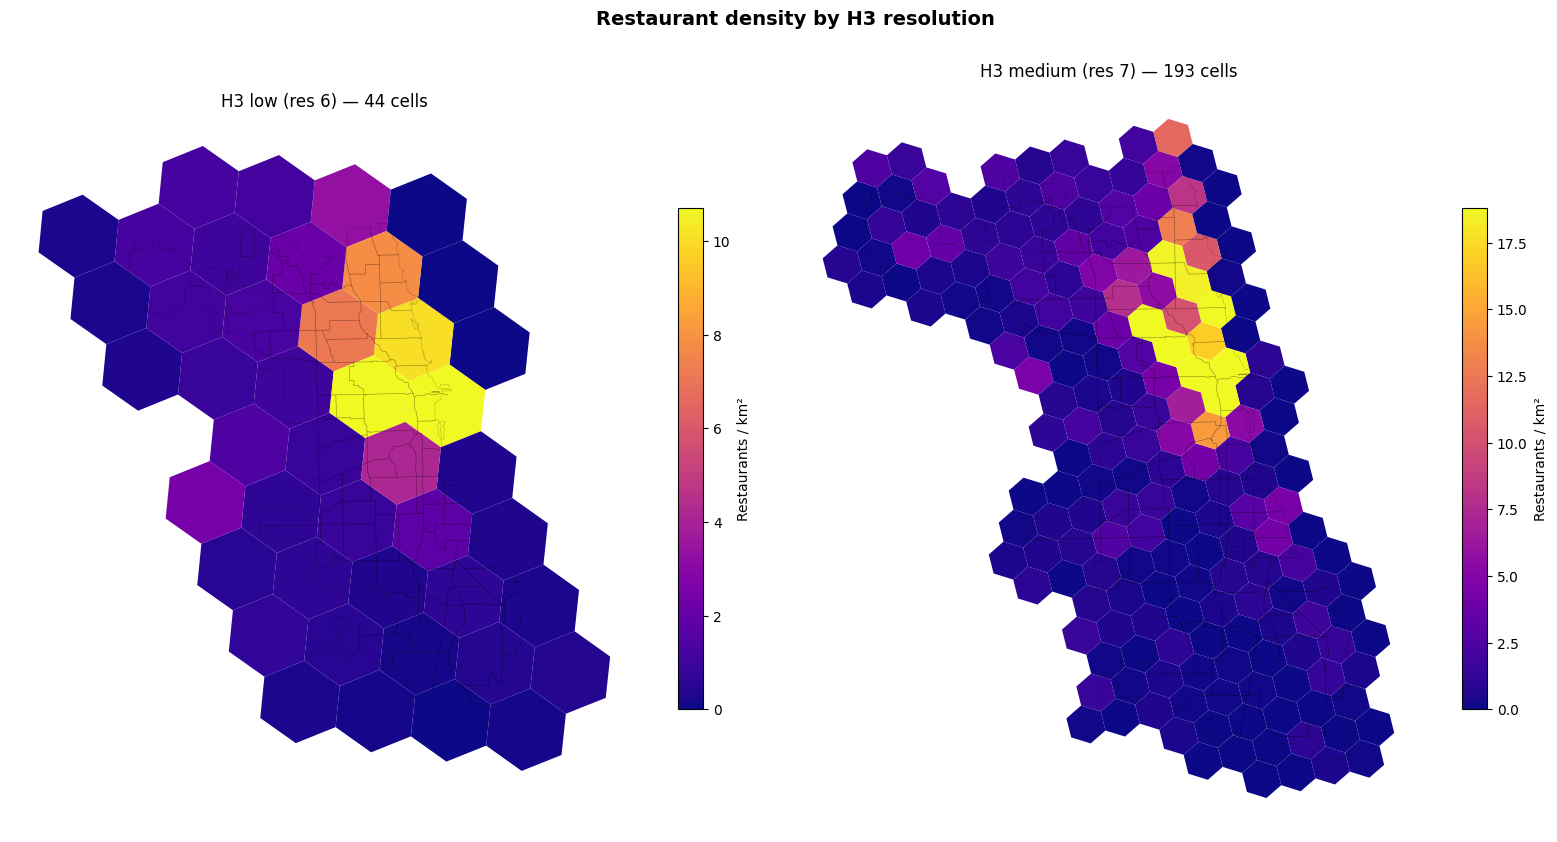

In [ ]:
def h3_features_to_gdf(res_name):
    sub = h3_features[h3_features["resolution"] == res_name].copy()
    sub["geometry"] = [Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(c)])
                       for c in sub["h3_cell"]]
    return gpd.GeoDataFrame(sub, geometry="geometry", crs=4326)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
for ax, (res_name, res_level) in zip(axes, RESOLUTIONS.items()):
    g = h3_features_to_gdf(res_name)
    vmax = g["restaurants_per_km2"].quantile(0.97)
    community_areas.boundary.plot(ax=ax, color="black", linewidth=0.3, alpha=0.3)
    g.plot(column="restaurants_per_km2", cmap="plasma", vmax=vmax, legend=True,
           legend_kwds={"label": "Restaurants / km²", "shrink": 0.6},
           edgecolor="none", ax=ax)
    ax.set_title(f"H3 {res_name} (res {res_level}) — {len(g):,} cells"); ax.set_axis_off()
plt.suptitle("Restaurant density by H3 resolution", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## Outputs

| File | Key | Rows |
|---|---|---|
| `data/poi/poi_features_community_area.parquet` | `community_area` | 77 |
| `data/poi/poi_features_h3.parquet` | `resolution` + `h3_cell` | hexagons × 2 res |

These are consumed by `01_07_Data_Aggregation`, which joins them onto each demand grid by the cell id. Distances are directly comparable; for counts prefer the `*_per_km2` density columns when comparing cells of different size.

> **Caveat:** densities use the *full* cell area, including water. A lakefront cell > with ~0 POIs gets ~0 density — harmless for analysis, but keep it in mind.